Nama: Prieyuda Akadita S
NIM: 240401010353
Kelas: IF403

In [1]:
print("Install library... harap tunggu")
!python -m pip install -q pandas numpy requests scipy matplotlib seaborn
print("Library berhasil diinstal")

Install library... harap tunggu
Library berhasil diinstal


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100

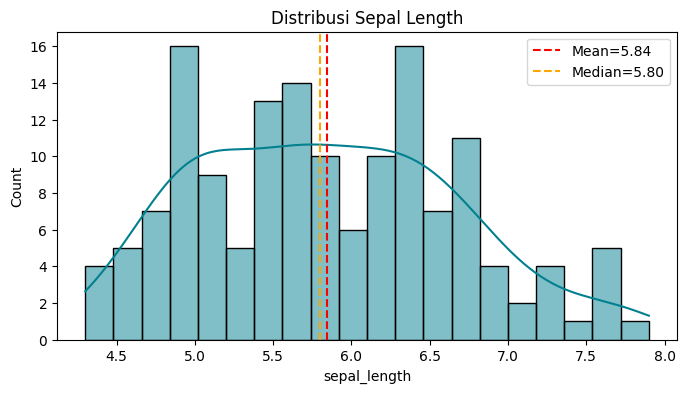

C:\Users\Prieyuda Akadita S\AppData\Local\Temp\ipykernel_7648\537053363.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=axes[0])
C:\Users\Prieyuda Akadita S\AppData\Local\Temp\ipykernel_7648\537053363.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', ax=axes[1])


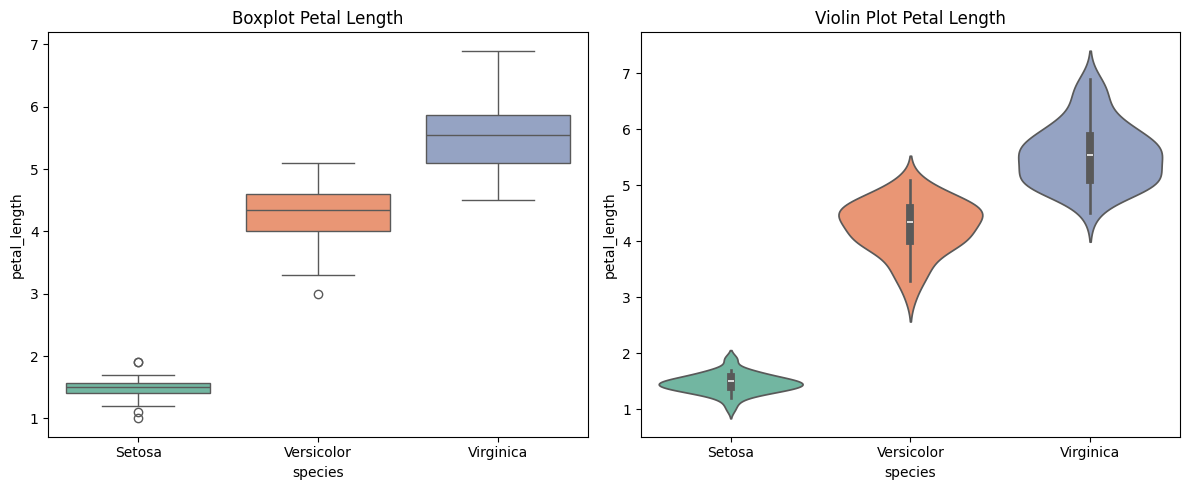


Matriks Korelasi:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


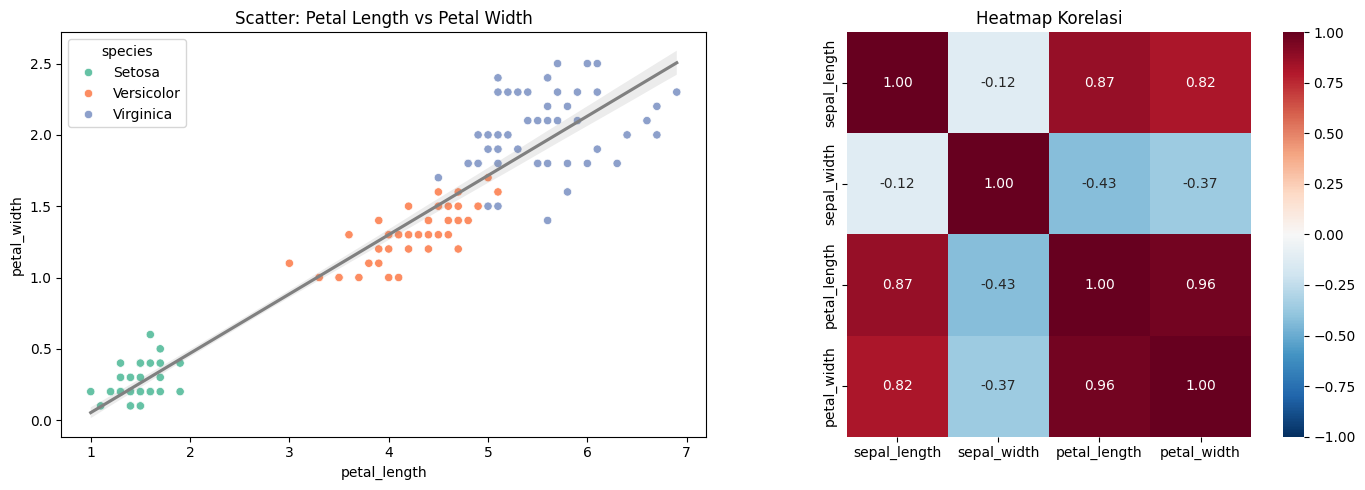

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Langkah 1: Load dataset via HTTP call
# Kita menggunakan URL raw dari repositori resmi scikit-learn atau UCI
url = "https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv"
df = pd.read_csv(url)

# Menyamakan nama kolom agar sesuai dengan kode Anda (lowercase)
df.columns = [col.lower().replace('.', '_') for col in df.columns]
# Jika kolom terakhir bernama 'variety', ubah ke 'species'
df.rename(columns={'variety': 'species'}, inplace=True)

print('Shape:', df.shape)
print(df.dtypes)
print(df.head())
print(df.describe().round(3))

# Langkah 2: Memperbaiki sintaks 'for' yang hilang
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f' Mean     : {col.mean():.3f}')
    print(f' Median   : {col.median():.3f}')
    print(f' Std Dev  : {col.std():.3f}')
    print(f' Skewness : {col.skew():.3f}')

# Langkah 3: Visualisasi Distribusi
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True, color='#028090', bins=20, ax=ax)
ax.axvline(df['sepal_length'].mean(), color='red', linestyle='--', label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange', linestyle='--', label=f"Median={df['sepal_length'].median():.2f}")
ax.set_title('Distribusi Sepal Length')
ax.legend()
plt.show()

# Langkah 4: Boxplot & Violin Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot Petal Length')
sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('Violin Plot Petal Length')
plt.tight_layout()
plt.show()

# Langkah 5: Matriks Korelasi
# Pastikan hanya kolom numerik yang dihitung korelasinya
corr = df.select_dtypes(include=[np.number]).corr(method='pearson')
print("\nMatriks Korelasi:")
print(corr.round(3))

# Mencari pasangan dengan korelasi tertinggi (selain angka 1.00)
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.mask(mask)
max_pair = corr_masked.stack().idxmax()
max_val = corr_masked.stack().max()

print(f'\nKorelasi tertinggi: {max_pair} = {max_val:.3f}')

# Langkah 6: Scatter Plot & Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width', scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

Kesimpulan:
Belajar statistik dasar dan analisis data dg dataset bunga iris